## Markowitz portfolio optimization in Python using cvxopt


In [ ]:
import sys
import subprocess

def install_package(package):
    """Install a package using pip."""
    subprocess.check_call([sys.executable, "-m", "pip", "install", package, "--quiet"])

required_packages = [
    "numpy>=1.21.0",
    "pandas>=1.3.0",
    "matplotlib>=3.4.0",
    "cvxopt>=1.2.0",
    "yfinance>=0.1.87"
]

print("Checking and installing dependencies...")
for package in required_packages:
    try:
        package_name = package.split(">=")[0].split("==")[0]
        if package_name == "cvxopt":
            __import__("cvxopt")
        elif package_name == "yfinance":
            __import__("yfinance")
        else:
            __import__(package_name.replace("-", "_"))
        print(f"✓ {package_name} already installed")
    except ImportError:
        print(f"Installing {package}...")
        try:
            install_package(package)
            print(f"✓ {package} installed successfully")
        except Exception as e:
            print(f"✗ Error installing {package}: {e}")

print("\nAll dependencies checked!")


Checking and installing dependencies...
✓ numpy already installed
✓ pandas already installed
✓ matplotlib already installed
Installing cvxopt>=1.2.0...



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: /usr/local/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip


✓ cvxopt>=1.2.0 installed successfully
✓ yfinance already installed

All dependencies checked!


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import cvxopt as opt
from cvxopt import blas, solvers
import pandas as pd
import yfinance as yf
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Turn off progress printing 
solvers.options['show_progress'] = False

print("Libraries imported successfully")

Libraries imported successfully


We will download real historical stock data for a portfolio of assets. 
4 diverse assets: a tech stock (AAPL), a commodity ETF (GLD), an energy stock (XOM), and a bond ETF (TLT).

In [ ]:
tickers = ['AAPL', 'GLD', 'XOM', 'TLT']
n_assets = len(tickers)
end_date = datetime.now()
start_date = end_date - timedelta(days=5*365)
print(f"Downloading data for {tickers} from {start_date.date()} to {end_date.date()}...")
data = yf.download(tickers, start=start_date, end=end_date, progress=False)
if len(tickers) == 1:
    prices = data['Close'].to_frame()
    prices.columns = tickers
else:
    prices = data['Close']
returns = prices.pct_change().dropna()
return_vec = returns.T.values

print(f"\nData downloaded successfully!")
print(f"Number of assets: {n_assets}")
print(f"Number of observations: {return_vec.shape[1]}")
print(f"Date range: {returns.index[0].date()} to {returns.index[-1].date()}")
print(f"\nFirst few returns:")
print(returns.head())
print(f"\nReturn statistics:")
print(returns.describe())


Data downloaded successfully!
Number of assets: 4
Number of observations: 1254
Date range: 2021-01-12 to 2026-01-08

First few returns:
Ticker          AAPL       GLD       TLT       XOM
Date                                              
2021-01-12 -0.001396  0.006474 -0.000795  0.022203
2021-01-13  0.016227 -0.004307  0.011262  0.011278
2021-01-14 -0.015127 -0.000519 -0.009368  0.039033
2021-01-15 -0.013731 -0.012408  0.003968 -0.048102
2021-01-19  0.005427  0.008473  0.003227  0.019837

Return statistics:
Ticker         AAPL          GLD          TLT          XOM
count   1254.000000  1254.000000  1254.000000  1254.000000
mean       0.000730     0.000739    -0.000261     0.001076
std        0.017498     0.009812     0.010103     0.017024
min       -0.092456    -0.064269    -0.034182    -0.078853
25%       -0.007933    -0.004653    -0.007017    -0.008921
50%        0.000944     0.000666    -0.000215     0.001251
75%        0.009785     0.006216     0.005949     0.011529
max        0.1

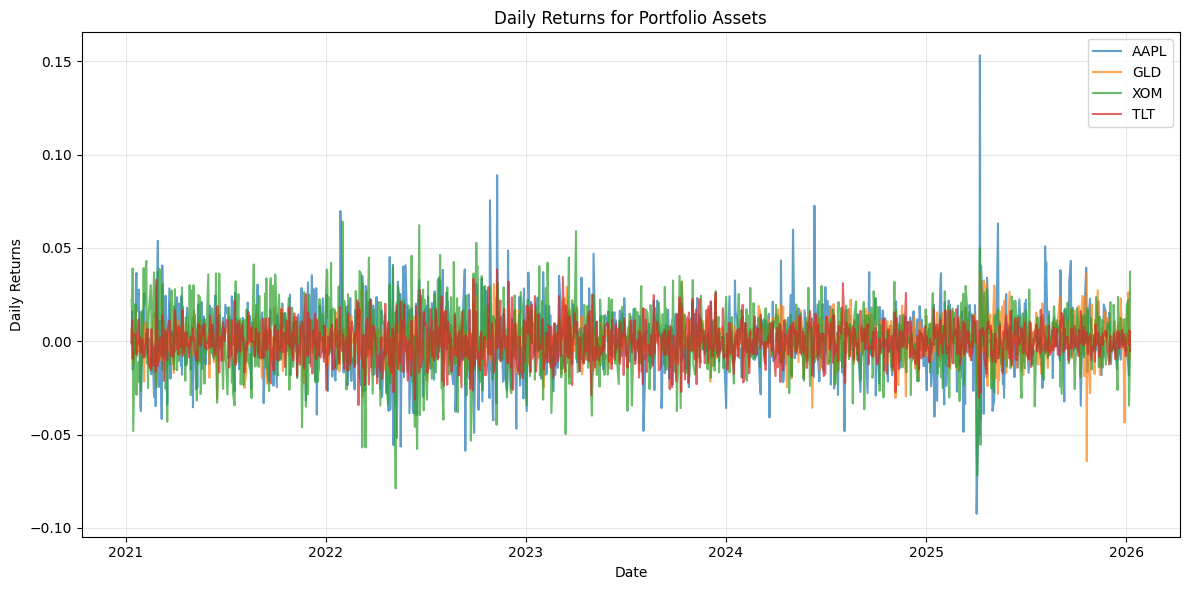

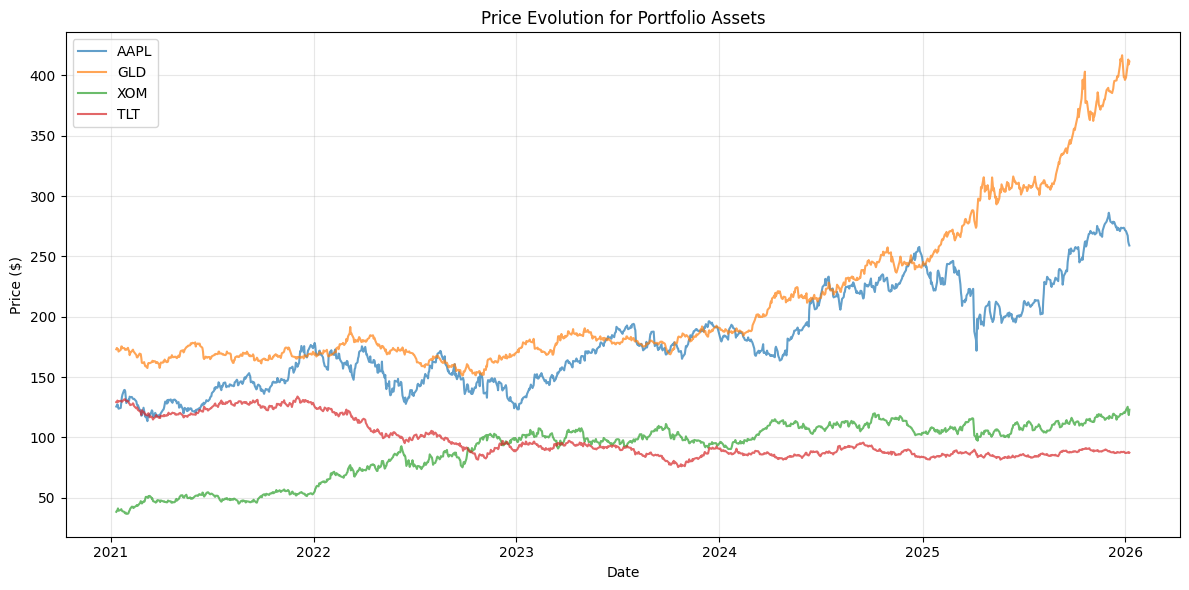

In [4]:
plt.figure(figsize=(12, 6))
for i, ticker in enumerate(tickers):
    plt.plot(returns.index, returns[ticker], alpha=0.7, label=ticker)
plt.xlabel('Date')
plt.ylabel('Daily Returns')
plt.title('Daily Returns for Portfolio Assets')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
for i, ticker in enumerate(tickers):
    plt.plot(prices.index, prices[ticker], alpha=0.7, label=ticker)
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.title('Price Evolution for Portfolio Assets')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

These return series allow the construction of many portfolios with varying levels of return and risk (standard deviation). By generating random portfolio weights that sum to one, we ensure full capital allocation and can visualize the resulting portfolios.

In [ ]:
def rand_weights(n):
    k = np.random.rand(n)
    return k / sum(k)

print(rand_weights(n_assets))
print(rand_weights(n_assets))

[0.39714363 0.14213144 0.23292366 0.22780127]
[0.30969225 0.09487702 0.41074232 0.18468841]


Next, we evaluate the performance of the random portfolios by computing their mean returns and volatility

In [ ]:
def random_portfolio(returns):
    p = np.asmatrix(np.mean(returns, axis=1))
    w = np.asmatrix(rand_weights(returns.shape[0]))
    C = np.asmatrix(np.cov(returns))
    
    mu = w * p.T
    sigma = np.sqrt(w * C * w.T)

    if sigma > 2:
        return random_portfolio(returns)
    return mu, sigma

In [7]:
n_portfolios = 500
means, stds = np.column_stack([
    random_portfolio(return_vec) 
    for _ in range(n_portfolios)
])

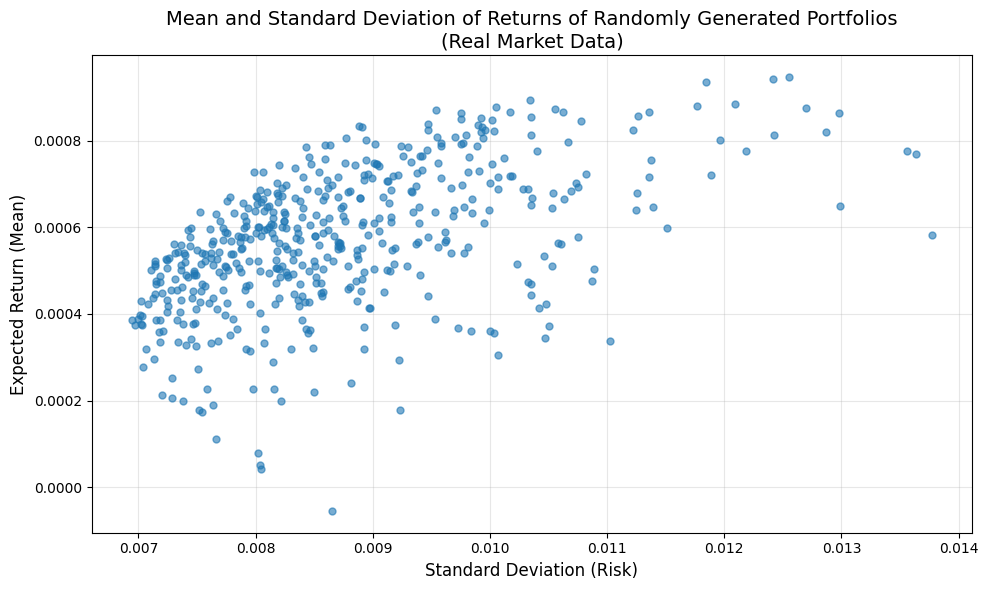

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(stds, means, 'o', markersize=5, alpha=0.6)
plt.xlabel('Standard Deviation (Risk)', fontsize=12)
plt.ylabel('Expected Return (Mean)', fontsize=12)
plt.title('Mean and Standard Deviation of Returns of Randomly Generated Portfolios\n(Real Market Data)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Markowitz Optimization and the Efficient Frontier

Once we have a clear representation of our portfolios (shown as blue dots), we can compute the efficient frontier using the Markowitz framework. This is achieved by **minimizing the portfolio variance**:

$$ w^T C w $$

subject to the following constraints:

- the expected portfolio return is fixed:
$$ R^T w $$

- the sum of the portfolio weights equals 1:
$$ \sum_{i} w_i = 1 $$

This optimization identifies the portfolios that offer the best risk–return trade-off, forming the **efficient frontier**.


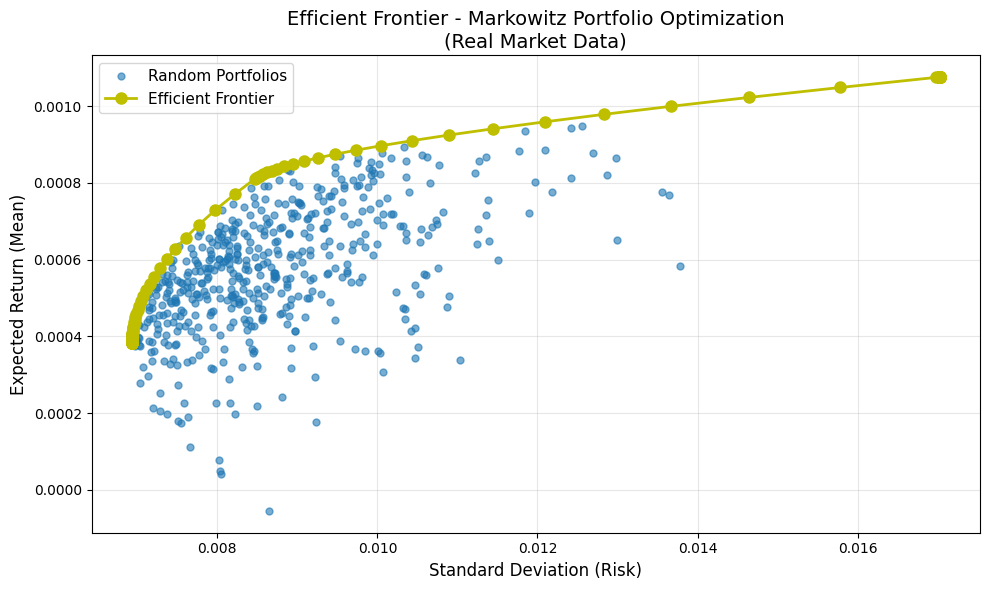

In [ ]:
def optimal_portfolio(returns):
    n = len(returns)
    returns = np.asmatrix(returns)
    
    N = 100
    mus = [10**(5.0 * t/N - 1.0) for t in range(N)]
    
    S = opt.matrix(np.cov(returns))
    pbar = opt.matrix(np.mean(returns, axis=1))
    
    G = -opt.matrix(np.eye(n))   
    h = opt.matrix(0.0, (n ,1))
    A = opt.matrix(1.0, (1, n))
    b = opt.matrix(1.0)
    
    portfolios = [solvers.qp(mu*S, -pbar, G, h, A, b)['x'] 
                  for mu in mus]
    frontier_returns = [blas.dot(pbar, x) for x in portfolios]
    frontier_risks = [np.sqrt(blas.dot(x, S*x)) for x in portfolios]
    m1 = np.polyfit(frontier_returns, frontier_risks, 2)
    x1 = np.sqrt(m1[2] / m1[0])
    wt = solvers.qp(opt.matrix(x1 * S), -pbar, G, h, A, b)['x']
    return np.asarray(wt), frontier_returns, frontier_risks

weights, frontier_returns, frontier_risks = optimal_portfolio(return_vec)

plt.figure(figsize=(10, 6))
plt.plot(stds, means, 'o', markersize=5, alpha=0.6, label='Random Portfolios')
plt.plot(frontier_risks, frontier_returns, 'y-o', linewidth=2, markersize=8, label='Efficient Frontier')
plt.ylabel('Expected Return (Mean)', fontsize=12)
plt.xlabel('Standard Deviation (Risk)', fontsize=12)
plt.title('Efficient Frontier - Markowitz Portfolio Optimization\n(Real Market Data)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In yellow you can see the optimal portfolios for each of the desired returns (i.e. the `mus`). In addition, we get the one optimal portfolio returned:

In [10]:
print("Optimal Portfolio Weights:")
print("=" * 50)
for ticker, weight in zip(tickers, weights.flatten()):
    print(f"{ticker:6s}: {weight*100:7.2f}%")
print("=" * 50)
print(f"Total: {weights.sum()*100:.2f}%")

# Display as DataFrame for better visualization
weights_df = pd.DataFrame({
    'Asset': tickers,
    'Weight': weights.flatten(),
    'Weight (%)': weights.flatten() * 100
})
print("\nOptimal Portfolio Allocation:")
print(weights_df.to_string(index=False))

Optimal Portfolio Weights:
AAPL  :    0.00%
GLD   :    0.00%
XOM   :    0.00%
TLT   :  100.00%
Total: 100.00%

Optimal Portfolio Allocation:
Asset   Weight  Weight (%)
 AAPL 0.000003    0.000286
  GLD 0.000004    0.000376
  XOM 0.000003    0.000265
  TLT 0.999991   99.999073


## Backtesting on Real Market Data

We'll implement a rolling window approach where we:

1. Use a lookback window (e.g., 252 trading days = 1 year)
2. Calculate optimal weights based on historical returns
3. Rebalance the portfolio periodically
4. Track performance over time

This approach uses real market data and demonstrates how portfolio optimization works in practice.

In [ ]:
backtest_tickers = ['AAPL', 'GLD', 'XOM', 'TLT', 'MSFT', 'IBM', 'SHY']
n_backtest_assets = len(backtest_tickers)
backtest_end = datetime.now()
backtest_start = backtest_end - timedelta(days=10*365)

print(f"Downloading backtest data for {backtest_tickers}...")
print(f"Date range: {backtest_start.date()} to {backtest_end.date()}")

backtest_data = yf.download(backtest_tickers, start=backtest_start, end=backtest_end, progress=False)

if len(backtest_tickers) == 1:
    backtest_prices = backtest_data['Close'].to_frame()
    backtest_prices.columns = backtest_tickers
else:
    backtest_prices = backtest_data['Close']

backtest_prices = backtest_prices.dropna(axis=1, how='all')

print(f"\nBacktest data shape: {backtest_prices.shape}")
print(f"Date range: {backtest_prices.index[0].date()} to {backtest_prices.index[-1].date()}")
print(f"\nFirst few prices:")
print(backtest_prices.head())

Date range: 2016-01-12 to 2026-01-09

Backtest data shape: (2513, 7)
Date range: 2016-01-12 to 2026-01-08

First few prices:
Ticker           AAPL         GLD        IBM       MSFT        SHY        TLT  \
Date                                                                            
2016-01-12  22.537882  104.209999  83.095116  46.214725  70.125252  94.476295   
2016-01-13  21.958420  104.720001  82.013428  45.216530  70.166687  95.407547   
2016-01-14  22.438669  103.019997  83.101387  46.503685  70.183281  94.514465   
2016-01-15  21.899796  104.080002  81.300659  44.647377  70.241325  95.987694   
2016-01-19  21.793825  103.980003  80.100212  44.270870  70.233025  95.689957   

Ticker            XOM  
Date                   
2016-01-12  48.526936  
2016-01-13  48.817333  
2016-01-14  51.056549  
2016-01-15  50.062771  
2016-01-19  49.301315  


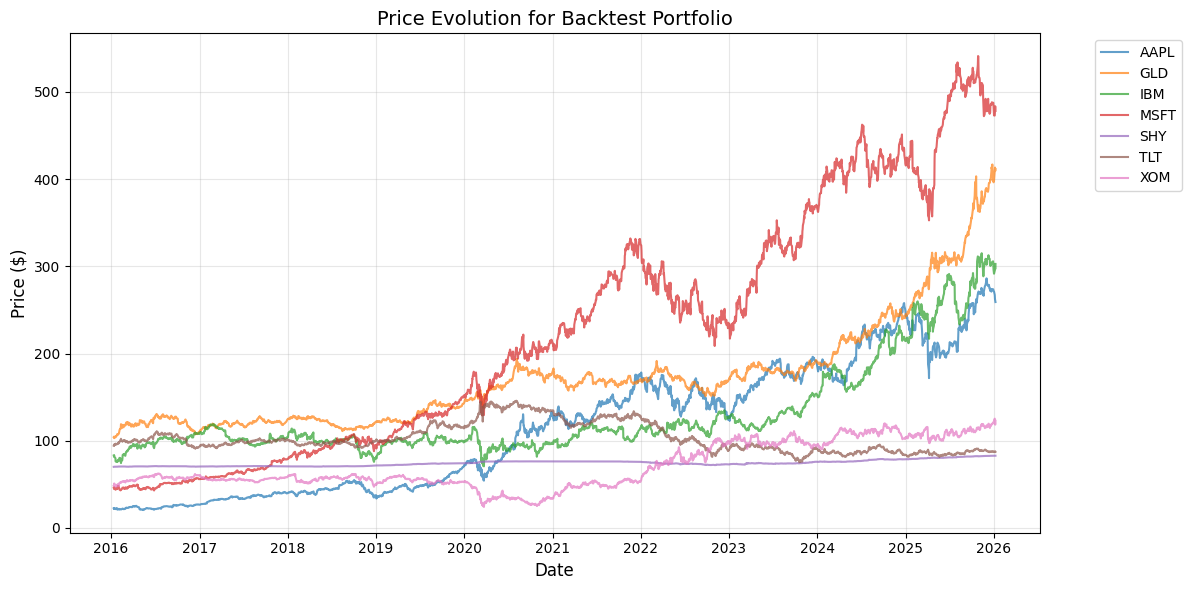

In [12]:
plt.figure(figsize=(12, 6))
for ticker in backtest_prices.columns:
    plt.plot(backtest_prices.index, backtest_prices[ticker], alpha=0.7, label=ticker)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.title('Price Evolution for Backtest Portfolio', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Now we'll implement a simple backtesting framework that:
1. Uses a rolling window 252d to calculate optimal weights
2. Rebalances the portfolio monthly
3. Tracks portfolio value over time
4. Compares against a simple equal-weight benchmark

Running Markowitz portfolio backtest...
Lookback period: 252 days (1 year)
Rebalance frequency: 21 days (monthly)
Initial capital: $100,000



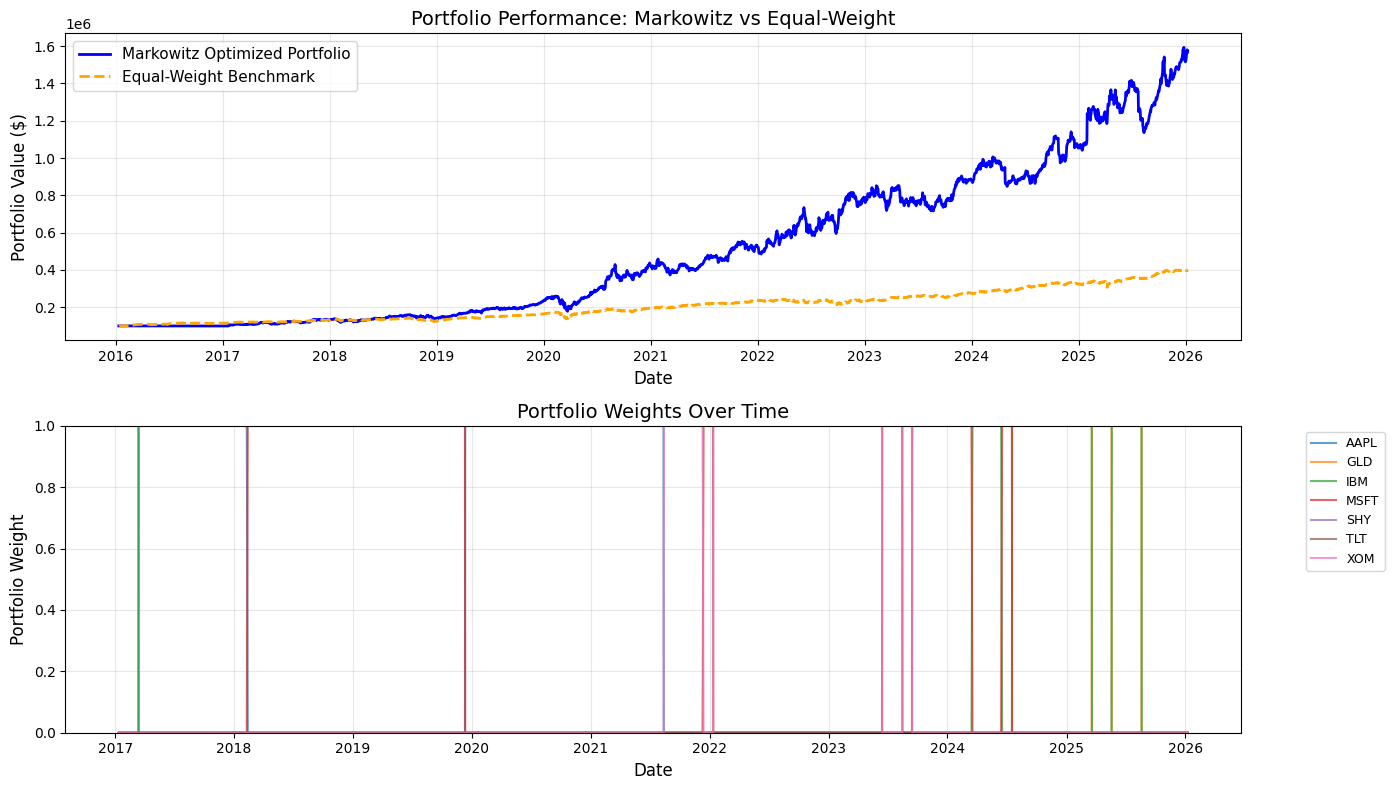


BACKTEST PERFORMANCE SUMMARY

Metric                         Markowitz            Equal-Weight        
------------------------------------------------------------
Total Return                           1474.11%          300.57%
Annualized Sharpe Ratio                   1.16            1.25
Maximum Drawdown                        -31.43%          -20.27%
Final Portfolio Value          $  1,574,110.34 $    398,336.83


In [ ]:
def backtest_markowitz(prices, lookback=252, rebalance_freq=21, initial_capital=100000):
   
    returns = prices.pct_change().dropna()
    portfolio_value = pd.Series(index=prices.index, dtype=float)
    weights_history = pd.DataFrame(index=prices.index, columns=prices.columns, dtype=float)
    
    portfolio_value.iloc[:lookback+1] = initial_capital
    
    current_weights = None
    
    for i in range(lookback + 1, len(prices)):
        if i % rebalance_freq == 0 or current_weights is None:
            current_date = prices.index[i]
            if current_date in returns.index:
                return_idx = returns.index.get_loc(current_date)
                start_idx = max(0, return_idx - lookback)
                hist_returns = returns.iloc[start_idx:return_idx]
            else:
                if i > 0:
                    prev_date = prices.index[i-1]
                    if prev_date in returns.index:
                        return_idx = returns.index.get_loc(prev_date)
                        start_idx = max(0, return_idx - lookback)
                        hist_returns = returns.iloc[start_idx:return_idx]
                    else:
                        hist_returns = returns.iloc[max(0, len(returns)-lookback):]
                else:
                    hist_returns = returns.iloc[max(0, len(returns)-lookback):]
            
            valid_assets = hist_returns.columns[hist_returns.notna().all()]
            if len(valid_assets) < 2:
                if current_weights is None:
                    current_weights = pd.Series(1.0/len(prices.columns), 
                                              index=prices.columns)
            else:
                try:
                    hist_returns_valid = hist_returns[valid_assets].T.values
                    weights, _, _ = optimal_portfolio(hist_returns_valid)
                    
                    current_weights = pd.Series(0.0, index=prices.columns)
                    for j, asset in enumerate(valid_assets):
                        current_weights[asset] = weights[j, 0]
                    
                    current_weights = current_weights / current_weights.sum()
                except:
                    if current_weights is None:
                        current_weights = pd.Series(1.0/len(prices.columns), 
                                                  index=prices.columns)
        
        current_date = prices.index[i]
        if current_weights is None:
            current_weights = pd.Series(1.0/len(prices.columns), index=prices.columns)
        weights_history.loc[current_date] = current_weights
        
        if current_date in returns.index:
            asset_returns = returns.loc[current_date]
            portfolio_return = (current_weights * asset_returns).sum()
            prev_value = portfolio_value.iloc[i-1]
            if pd.isna(prev_value):
                prev_value = initial_capital
            portfolio_value.iloc[i] = prev_value * (1 + portfolio_return)
        else:
            prev_value = portfolio_value.iloc[i-1]
            if pd.isna(prev_value):
                prev_value = initial_capital
            portfolio_value.iloc[i] = prev_value
    
    portfolio_value = portfolio_value.ffill().fillna(initial_capital)
    
    return portfolio_value, weights_history

print("Running Markowitz backtest..")
print(f"Lookback period: 252 ")
print(f"Rebalance frequency: 21d")
print(f"Initial capital: $100,000\n")

portfolio_value, weights_history = backtest_markowitz(
    backtest_prices, 
    lookback=252, 
    rebalance_freq=21,
    initial_capital=100000
)

equal_weights = 1.0 / len(backtest_prices.columns)
backtest_returns = backtest_prices.pct_change().dropna()
benchmark_returns = (backtest_returns * equal_weights).sum(axis=1)
benchmark_value = (1 + benchmark_returns).cumprod() * 100000

plt.figure(figsize=(14, 8))

plt.subplot(2, 1, 1)
plt.plot(portfolio_value.index, portfolio_value.values, 
         linewidth=2, label='Markowitz Optimized Portfolio', color='blue')
plt.plot(benchmark_value.index, benchmark_value.values, 
         linewidth=2, label='Equal-Weight Benchmark', color='orange', linestyle='--')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value ($)', fontsize=12)
plt.title('Portfolio Performance: Markowitz vs Equal-Weight', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
for col in weights_history.columns:
    plt.plot(weights_history.index, weights_history[col], 
             alpha=0.7, label=col, linewidth=1.5)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Weight', fontsize=12)
plt.title('Portfolio Weights Over Time', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.ylim([0, 1])

plt.tight_layout()
plt.show()

portfolio_value_clean = portfolio_value.dropna()
benchmark_value_clean = benchmark_value.dropna()

if len(portfolio_value_clean) > 0 and portfolio_value_clean.iloc[0] > 0:
    total_return_markowitz = (portfolio_value_clean.iloc[-1] / portfolio_value_clean.iloc[0] - 1) * 100
    markowitz_returns = portfolio_value_clean.pct_change().dropna()
    if len(markowitz_returns) > 0 and markowitz_returns.std() > 0:
        sharpe_markowitz = (markowitz_returns.mean() / markowitz_returns.std()) * np.sqrt(252)
    else:
        sharpe_markowitz = 0.0
    max_dd_markowitz = ((portfolio_value_clean / portfolio_value_clean.expanding().max()) - 1).min() * 100
    final_value_markowitz = portfolio_value_clean.iloc[-1]
else:
    total_return_markowitz = 0.0
    sharpe_markowitz = 0.0
    max_dd_markowitz = 0.0
    final_value_markowitz = initial_capital

if len(benchmark_value_clean) > 0 and benchmark_value_clean.iloc[0] > 0:
    total_return_benchmark = (benchmark_value_clean.iloc[-1] / benchmark_value_clean.iloc[0] - 1) * 100
    benchmark_returns_series = benchmark_value_clean.pct_change().dropna()
    if len(benchmark_returns_series) > 0 and benchmark_returns_series.std() > 0:
        sharpe_benchmark = (benchmark_returns_series.mean() / benchmark_returns_series.std()) * np.sqrt(252)
    else:
        sharpe_benchmark = 0.0
    max_dd_benchmark = ((benchmark_value_clean / benchmark_value_clean.expanding().max()) - 1).min() * 100
    final_value_benchmark = benchmark_value_clean.iloc[-1]
else:
    total_return_benchmark = 0.0
    sharpe_benchmark = 0.0
    max_dd_benchmark = 0.0
    final_value_benchmark = initial_capital

print("\n" + "="*60)
print("BACKTEST PERFORMANCE SUMMARY")
print("="*60)
print(f"\n{'Metric':<30} {'Markowitz':<20} {'Equal-Weight':<20}")
print("-"*60)
print(f"{'Total Return':<30} {total_return_markowitz:>15.2f}% {total_return_benchmark:>15.2f}%")
print(f"{'Annualized Sharpe Ratio':<30} {sharpe_markowitz:>15.2f} {sharpe_benchmark:>15.2f}")
print(f"{'Maximum Drawdown':<30} {max_dd_markowitz:>15.2f}% {max_dd_benchmark:>15.2f}%")
print(f"{'Final Portfolio Value':<30} ${final_value_markowitz:>14,.2f} ${final_value_benchmark:>14,.2f}")
print("="*60)

The backtest compares the Markowitz-optimized portfolio to an equal-weight benchmark. Key takeaways:

Diversification: Weights adapt automatically to historical correlations and returns.

Risk-Return Tradeoff: Optimization aims to maximize returns for a given risk level.

Rebalancing: Regular adjustments keep the portfolio close to optimal weights.

Notes:

Past performance ≠ future results.

Optimization relies on historical data and may not predict future performance.

Transaction costs and slippage are excluded.

Results depend on the chosen assets and period.
